# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [61]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [62]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [63]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [64]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [65]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [66]:
# revisar el número de filas y columnas de cada dataset
print("plans:", plans.shape)
print("users:", users.shape)
print("usage:", usage.shape)

plans: (2, 8)
users: (4000, 8)
usage: (40000, 6)


In [67]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [68]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [69]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [70]:

# cantidad de nulos para users
print(users.isna().sum())
# proporción de nulos para users
print(users.isna().mean())
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')


user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [71]:
# cantidad de nulos para usage
print(usage.isna().sum())
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64



## Valores nulos

### Dataset `users`

- La columna `city` presenta 469 valores nulos, equivalentes al 11.7% del dataset.
  - Debido a que la proporción es moderada, se recomienda mantenerlos como nulos temporalmente y evaluar posteriormente si es necesario imputarlos o excluirlos dependiendo del análisis.

- La columna `churn_date` presenta 3,534 valores nulos, equivalentes al 88.35% del dataset.
  - No se considera un problema de calidad, ya que probablemente representa usuarios que continúan activos y no han abandonado el servicio. Se recomienda conservar la columna sin imputar.

### Dataset `usage`

- La columna `date` presenta únicamente 50 valores nulos.
  - Debido a su baja proporción respecto al total del dataset, estos registros pueden mantenerse como nulos o eliminarse posteriormente si afectan el análisis temporal.

- La columna `duration` presenta 22,076 valores nulos.
  - Esto probablemente ocurre porque la duración solamente aplica a registros de llamadas (`call`), por lo que los nulos podrían clasificarse como MAR (Missing At Random). Se recomienda investigar la relación con la columna `type`.

- La columna `length` presenta 17,896 valores nulos.
  - Esto probablemente ocurre porque la longitud solamente aplica a registros de mensajes (`text`). También podría clasificarse como MAR (Missing At Random), por lo que se recomienda validar esta relación antes de imputar o eliminar datos.


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [72]:
# explorar columnas numéricas de users

- La columna `user_id` funciona como identificador único de cada usuario. No presenta valores negativos ni anomalías visibles, por lo que no requiere limpieza.
- La columna `age` presentó valores inválidos representados por el sentinel -999. Este valor no corresponde a una edad real, por lo que fue reemplazado por la mediana para evitar distorsionar el análisis.

# explorar columnas numéricas de usage
- Las columnas id y user_id funcionan como identificadores y no presentan anomalías visibles.
- La columna duration contiene muchos valores nulos, pero esto parece depender del tipo de registro, ya que la duración solamente aplica a llamadas.
- La columna length también presenta muchos nulos, probablemente porque solo aplica a mensajes de texto.
No se observan valores negativos ni sentinels evidentes en estas columnas.

In [80]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']


- La columna city contiene varias ciudades válidas, pero también presenta valores faltantes y el sentinel "?". Se decidió reemplazar "?" por valores nulos (pd.NA).
- La columna plan solamente contiene dos categorías: Basico y Premium. No se detectaron inconsistencias ni errores ortográficos.

In [78]:

# explorar columna categórica de usage
usage['type'].value_counts()


text    22092
call    17908
Name: type, dtype: int64

- La columna type contiene únicamente las categorías call y text. No se encontraron valores inválidos ni categorías inesperadas.



Se encontraron valores inválidos o sentinels en las columnas age, city y reg_date.

- En age, el valor -999 fue reemplazado por la mediana.
- En city, el valor "?" fue convertido a nulo.
- En reg_date, las fechas del año 2026 fueron consideradas inconsistentes y convertidas a NaT.

Estas acciones permiten mantener la calidad del dataset sin eliminar información útil.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [81]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [82]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [83]:

# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()



2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, ... haz doble clic en este bloque y escribe qué ves.

In [84]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()


2024.0    39950
Name: date, dtype: int64

-En reg_date, se observan registros correspondientes a los años 2022, 2023 y 2024, que son coherentes con el período de análisis. Sin embargo, también aparecen 40 registros del año 2026, lo que representa fechas futuras fuera del rango esperado y probablemente errores de captura.
-En date, todos los registros corresponden al año 2024, lo cual es consistente con el período analizado en el proyecto.

Diagnóstico: Se identificaron fechas fuera de rango en reg_date, específicamente registros del año 2026. Debido a que el análisis se basa en información hasta 2024, estas fechas deben considerarse inconsistentes. Se recomienda convertirlas a valores nulos (NaT) para evitar distorsiones en el análisis temporal.

In [85]:

# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()

users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()


count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [86]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)


Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [87]:

# Convertir reg_date a formato fecha
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].describe()

count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

In [88]:
# Convertir date a formato fecha
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

# Marcar fechas futuras como NA para date
usage.loc[usage['date'].dt.year > 2024, 'date'] = pd.NaT

# Verificar cambios
usage['date'].describe()

count                             39950
unique                            39950
top       2024-06-16 13:26:59.770494262
freq                                  1
first               2024-01-01 00:00:00
last                2024-06-30 00:00:00
Name: date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [89]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].apply(lambda x: x.isna().mean())


type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [90]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(lambda x: x.isna().mean())


type
call    0.99933
text    0.00000
Name: length, dtype: float64

Los valores nulos en duration y length dependen directamente de la columna type.
En los registros call, la duración aplica correctamente y length aparece nula. En los registros text, ocurre lo contrario: length contiene valores y duration aparece nula.
Esto confirma un patrón MAR (Missing At Random), ya que los nulos dependen del tipo de servicio y no de errores de captura. Por ello, se decide conservarlos como nulos para evitar distorsionar el análisis.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [91]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int)
usage["is_call"] = (usage["type"] == "call").astype(int)

# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [92]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [93]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [94]:
# Resumen estadístico de las columnas numéricas
user_profile[[
    "age",
    "cant_mensajes",
    "cant_llamadas",
    "cant_minutos_llamada"
]].describe()


,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [95]:
# Distribución porcentual del tipo de plan
user_profile["plan"].value_counts(normalize=True) * 100


Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

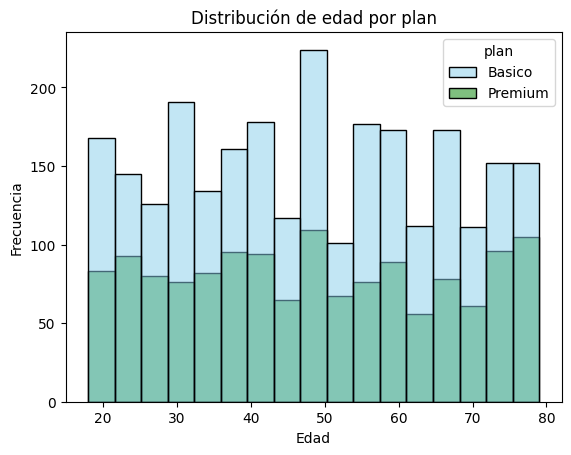

In [96]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile,
             x='age',
             hue='plan',
             palette=['skyblue', 'green'])

plt.title('Distribución de edad por plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- La distribución de edad es relativamente simétrica.
- No se observan diferencias muy marcadas entre los planes Básico y Premium.
- Ambos planes presentan usuarios distribuidos en distintos rangos de edad.

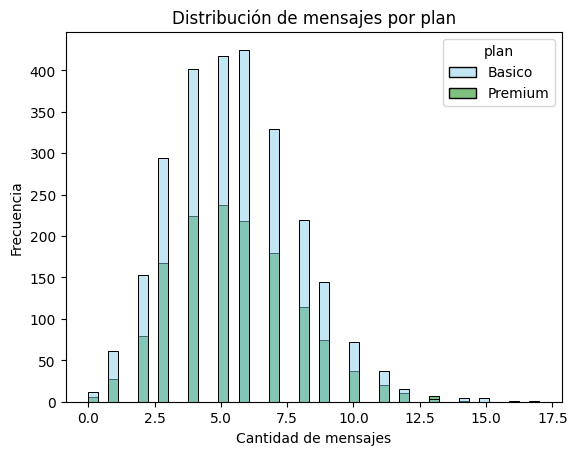

In [97]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile,
             x='cant_mensajes',
             hue='plan',
             palette=['skyblue', 'green'])

plt.title('Distribución de mensajes por plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.show()


💡Insights:
- La distribución está sesgada a la derecha.
- Los usuarios Premium tienden a enviar más mensajes que los usuarios Básico.
- La mayoría de los usuarios concentra cantidades bajas o medias de mensajes.

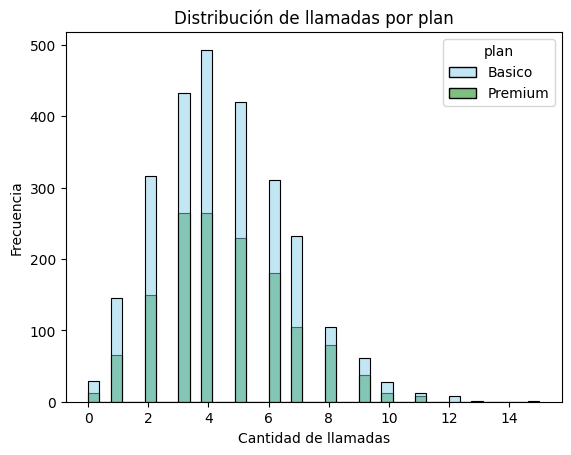

In [98]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile,
             x='cant_llamadas',
             hue='plan',
             palette=['skyblue', 'green'])

plt.title('Distribución de llamadas por plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.show()


💡Insights:
- La distribución presenta sesgo a la derecha.
- Los usuarios Premium muestran una mayor frecuencia de llamadas.
- La mayoría de los usuarios realiza una cantidad moderada de llamadas.

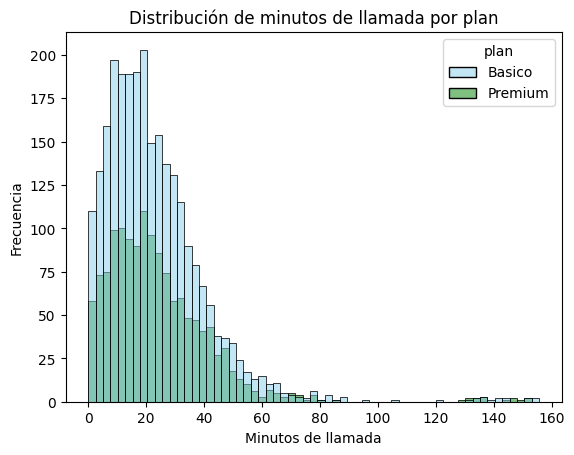

In [99]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile,
             x='cant_minutos_llamada',
             hue='plan',
             palette=['skyblue', 'green'])

plt.title('Distribución de minutos de llamada por plan')
plt.xlabel('Minutos de llamada')
plt.ylabel('Frecuencia')
plt.show()

💡Insights:
- La distribución está sesgada a la derecha.
- Los usuarios Premium tienden a acumular más minutos de llamadas.
- Existen usuarios con consumos considerablemente altos en comparación con el resto.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

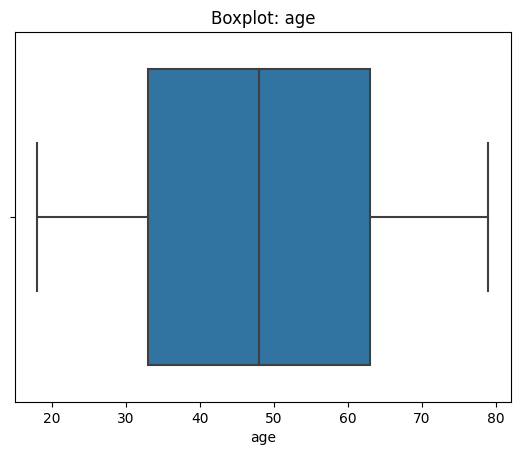

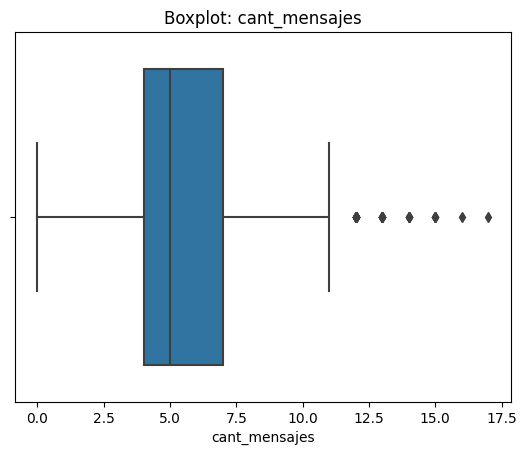

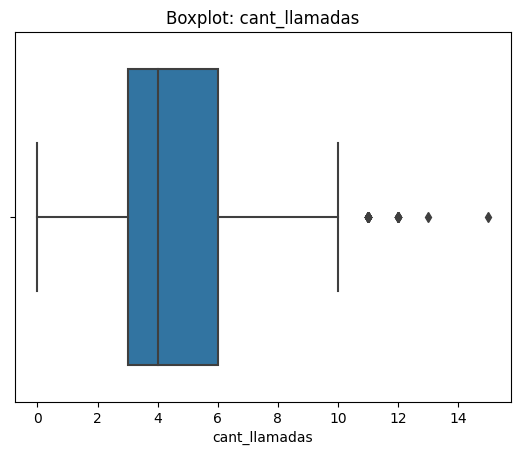

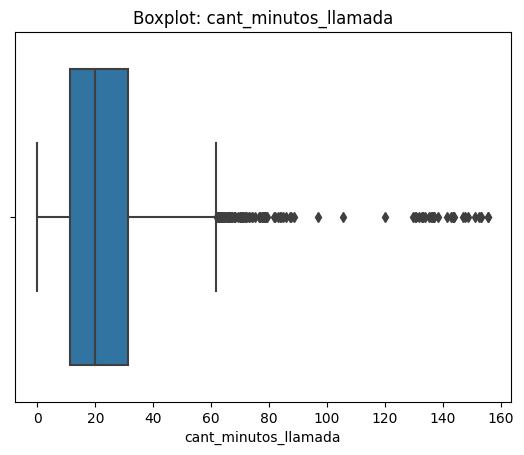

In [100]:
# Visualizando usando BoxPlot
columnas_numericas = [
    'age',
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]

for col in columnas_numericas:
    sns.boxplot(x=user_profile[col])
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights:

- age: La variable age no presenta outliers relevantes ni valores inconsistentes. La distribución de edades se mantiene dentro de rangos esperados para usuarios reales.
- cant_mensajes: presenta algunos outliers superiores, ya que el valor máximo (17) supera el límite IQR calculado (11.5). Sin embargo, estos valores parecen corresponder a usuarios con alta actividad y no a errores de captura, por lo que se decidió conservarlos.
- cant_llamadas: presenta valores superiores al límite calculado por IQR (10.5). Estos casos representan usuarios con mayor frecuencia de llamadas y son coherentes con el comportamiento esperado del servicio, por lo que no se eliminaron.
- cant_minutos_llamada: La variable cant_minutos_llamada presenta una fuerte asimetría positiva y numerosos outliers superiores. El valor máximo (155.69) supera ampliamente el límite calculado mediante IQR (61.86). Sin embargo, estos valores pueden representar usuarios intensivos del servicio y no evidencian errores de captura, por lo que se decidió mantenerlos para preservar información relevante del negocio.

In [101]:

# Calcular límites con el método IQR
columnas_limites = [
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]

for col in columnas_limites:

    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)

    IQR = Q3 - Q1

    limite_superior = Q3 + 1.5 * IQR

    print(f'{col}')
    print('Límite superior:', limite_superior)
    print('Valor máximo:', user_profile[col].max())
    print('---------------------')

cant_mensajes
Límite superior: 11.5
Valor máximo: 17.0
---------------------
cant_llamadas
Límite superior: 10.5
Valor máximo: 15.0
---------------------
cant_minutos_llamada
Límite superior: 61.8575
Valor máximo: 155.69
---------------------


---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [102]:
# Crear columna grupo_uso
def clasificar_uso(row):
    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo uso'
    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)

In [103]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [104]:
# Crear columna grupo_edad
def clasificar_edad(age):
    if age < 30:
        return 'Joven'
    elif age < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile['age'].apply(clasificar_edad)

In [105]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

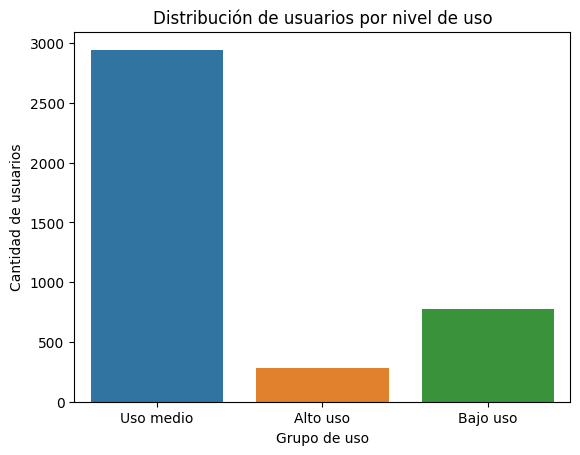

In [106]:
# Visualización de los segmentos por uso

sns.countplot(data=user_profile, x='grupo_uso')
plt.title('Distribución de usuarios por nivel de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()

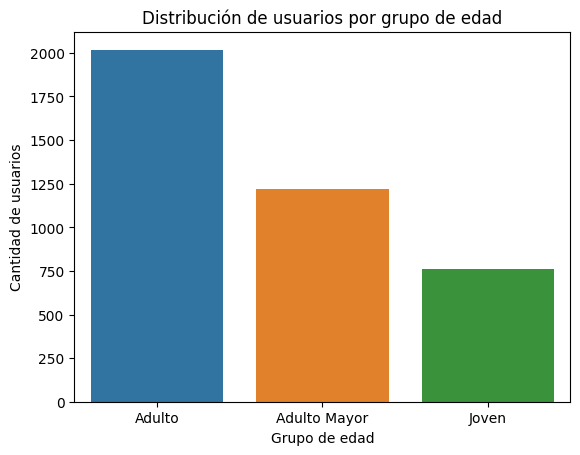

In [107]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad')
plt.title('Distribución de usuarios por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

Durante el análisis se identificaron varios problemas de calidad de datos:
- Existían valores sentinel en la columna age, específicamente -999, los cuales fueron reemplazados por la mediana para evitar distorsiones en el análisis.
- La columna city contenía valores "?", que fueron convertidos a valores nulos (pd.NA).
- Se detectaron fechas futuras en reg_date correspondientes al año 2026, aunque el dataset solo debía contener información hasta 2024. Estas fechas fueron marcadas como nulas.
- Las columnas duration y length contenían valores ausentes relacionados con el tipo de evento registrado, por lo que se consideraron datos MAR (Missing At Random) y se decidió conservarlos como nulos.
- También se detectaron outliers en las variables cant_mensajes, cant_llamadas y cant_minutos_llamada, pero se mantuvieron porque representan posibles usuarios reales de alto consumo.


🔍 **Segmentos por Edad**

Se identificaron tres segmentos principales de clientes:
    Joven: usuarios menores de 30 años.
    Adulto: usuarios entre 30 y 59 años.
    Adulto Mayor: usuarios de 60 años o más.
    
- El segmento predominante corresponde a los adultos, lo que indica que la mayor parte de la base de clientes pertenece a usuarios económicamente activos y potencialmente estables en sus hábitos de consumo.

- Los adultos mayores presentan un comportamiento más moderado, mientras que los jóvenes tienden a mostrar patrones de uso más variables.


📊 **Segmentos por Nivel de Uso**

Los clientes fueron clasificados en:
    Bajo uso
    Uso medio
    Alto uso
- La mayoría de los usuarios se concentra entre uso medio y alto, lo que sugiere que la plataforma tiene una base de clientes bastante activa.
- El segmento de alto uso representa una oportunidad importante para estrategias de fidelización, upgrades a planes premium y ofertas personalizadas.

➡️ Esto sugiere que ConnectaTel puede aprovechar estos patrones para diseñar planes más segmentados según comportamiento real de consumo.

Outliers y patrones extremos detectados: Se encontraron usuarios con niveles de llamadas, mensajes y duración considerablemente superiores al promedio.

Estos casos podrían representar:
- Clientes premium o corporativos.
- Usuarios intensivos con alto valor comercial.
- Posibles anomalías o automatizaciones.
Debido a que los valores máximos aún son razonables para un servicio de telecomunicaciones, se decidió conservarlos para no perder información relevante del negocio.


💡 **Recomendaciones**
- Diseñar planes diferenciados para usuarios de alto consumo.
- Crear promociones específicas para usuarios jóvenes y de uso medio para aumentar la fidelización.
- Implementar validaciones automáticas para evitar fechas futuras o valores sentinel en futuros registros.
- Monitorear continuamente los outliers para detectar oportunidades comerciales o posibles fraudes.
- Utilizar la segmentación creada para campañas de marketing personalizadas y estrategias de retención.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`